In [1]:
# Parameters
BATCH_MODE = "true"

# Qwen-Image 2.1 : workflows de reference et execution hebergee

Troisieme temps de la lignee Qwen-Image-Edit de la serie Image :
[01-5](01-5-Qwen-Image-Edit.ipynb) posait le modele et son API, [01-5b](01-5b-Qwen-Image-Edit-2509.ipynb)
passait a la revision 2509 et a l'edition multi-etapes. Ce carnet attaque le
palier **2.1** sous l'angle de l'outillage : les 12 workflows de reference
publies par l'editeur ComfyUI (nomadoor) sont **versionnes dans le depot** et
consommes ici comme source de verite, executes sur l'instance dediee
`comfyui-qwen` (palier INT8 de l'Epic d'hebergement).

Trois questions guident le parcours :

1. **Que change le palier INT8 ?** -- les trois fichiers heberges, leur place,
   et l'etat de l'instance qui les porte ;
2. **Comment passe-t-on du workflow UI au prompt API ?** -- les deux formats
   de ComfyUI, et la conversion mecanique de l'un a l'autre ;
3. **Que couvre reellement l'instance ?** -- un balayage live de l'inventaire
   `/object_info` tranche, workflow par workflow, ce qui est executable.

Le point de doctrine : le JSON versionne est la reference de l'editeur. Le
carnet ne recopie **pas** le workflow en dictionnaire inline -- il le charge,
le convertit, et toute divergence resterait visible dans le diff du fichier
versionne.

## 1. Le palier INT8 et l'instance hebergee

Qwen-Image 2.1 se deploie ici en quantification **INT8 des convolutions**
(`convrot`) : le fichier de diffusion passe de ~20 Go en bf16 a 7,26 Go, le
text encoder `qwen3vl_8b` a 9,35 Go, le VAE reste en bf16 (676 Mo). C'est ce
qui tient sur une carte grand public -- et c'est le choix de l'Epic
d'hebergement, avec sa garde de capacite disque au telechargement.

Les trois fichiers vivent sur l'instance `comfyui-qwen` (une RTX 3090
dediee), derriere une authentification Bearer. Le `MarkdownNote` embarque
dans chaque workflow nomadoor liste precisement ces fichiers avec leurs
liens Hugging Face : notre garde de coherence modele (§2) verifie que ce que
le carnet charge est exactement ce que le depot versionne.

In [2]:
# Dependances, configuration, authentification
import importlib.util

for module in ("PIL", "requests", "matplotlib", "dotenv"):
    if importlib.util.find_spec(module) is None:
        raise ImportError(f"Module manquant : {module} (pip install {module})")

import json
import os
import time
import uuid
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
from IPython.display import display
from PIL import Image

# Le .env de la serie GenAI porte l'URL et le token de l'instance
courant = Path.cwd()
for _ in range(5):
    if (courant / ".env").exists():
        load_dotenv(courant / ".env")
        break
    courant = courant.parent

COMFYUI_URL = os.getenv("COMFYUI_API_URL", "https://qwen-image-edit.myia.io").rstrip("/")
COMFYUI_TOKEN = os.getenv("COMFYUI_AUTH_TOKEN") or os.getenv("COMFYUI_API_TOKEN")
CLIENT_ID = str(uuid.uuid4())

if not COMFYUI_TOKEN:
    raise ValueError("COMFYUI_AUTH_TOKEN absent du .env -- voir scripts/genai-stack (audit d'auth)")

print("Endpoint :", COMFYUI_URL)
print("Token   : present (valeur jamais affichee)")

Endpoint : https://qwen-image-edit.myia.io
Token   : present (valeur jamais affichee)


## 2. Le client

Meme patron que [01-5b](01-5b-Qwen-Image-Edit-2509.ipynb) : une session
`requests` portant le jeton Bearer, quatre routes ComfyUI (`/system_stats`,
`/prompt`, `/history/<id>`, `/view`), et une boucle d'attente. La difference :
`executer` ne suppose plus un noeud de sortie a numero fixe -- il recolte les
images de toutes les sorties du historique, le workflow versionne fixant lui-meme
sa topologie.

In [3]:
class ClientQwenImage21:
    """Client ComfyUI pour l'instance qwen-image-edit (auth Bearer)."""

    def __init__(self, base_url: str, auth_token: str):
        self.base_url = base_url.rstrip("/")
        self.client_id = str(uuid.uuid4())
        self.session = requests.Session()
        self.session.headers.update({"Authorization": f"Bearer {auth_token}"})

    def system_stats(self) -> dict:
        reponse = self.session.get(f"{self.base_url}/system_stats", timeout=15)
        reponse.raise_for_status()
        return reponse.json()

    def object_info(self) -> dict:
        reponse = self.session.get(f"{self.base_url}/object_info", timeout=60)
        reponse.raise_for_status()
        return reponse.json()

    def soumettre(self, prompt_api: dict) -> str:
        payload = {"prompt": prompt_api, "client_id": self.client_id}
        reponse = self.session.post(f"{self.base_url}/prompt", json=payload, timeout=30)
        reponse.raise_for_status()
        return reponse.json()["prompt_id"]

    def attendre(self, prompt_id: str, timeout: int = 900) -> dict:
        debut = time.time()
        while time.time() - debut < timeout:
            reponse = self.session.get(f"{self.base_url}/history/{prompt_id}", timeout=15)
            if reponse.status_code == 200:
                historique = reponse.json()
                if prompt_id in historique:
                    return historique[prompt_id]
            time.sleep(2)
        raise TimeoutError(f"Workflow {prompt_id} sans reponse apres {timeout} s")

    def image(self, nom: str, sous_dossier: str = "", type_fichier: str = "output") -> Image.Image:
        params = {"filename": nom, "subfolder": sous_dossier, "type": type_fichier}
        reponse = self.session.get(f"{self.base_url}/view", params=params, timeout=120)
        reponse.raise_for_status()
        return Image.open(BytesIO(reponse.content))

    def executer(self, prompt_api: dict, timeout: int = 900) -> list:
        prompt_id = self.soumettre(prompt_api)
        resultat = self.attendre(prompt_id, timeout)
        if resultat.get("status", {}).get("status_str") == "error":
            extrait = json.dumps(resultat.get("status", {}))[:400]
            raise RuntimeError(f"Execution en erreur cote instance : {extrait}")
        images = []
        for sortie in resultat.get("outputs", {}).values():
            for donnee in sortie.get("images", []):
                images.append(self.image(donnee["filename"], donnee.get("subfolder", ""), donnee.get("type", "output")))
        return images


client = ClientQwenImage21(COMFYUI_URL, COMFYUI_TOKEN)
stats = client.system_stats()
systeme = stats.get("system", {})
periph = stats.get("devices", [{}])[0]
print("ComfyUI    :", systeme.get("comfyui_version", "?"))
print("Python     :", systeme.get("python_version", "?"))
print("GPU        :", periph.get("name", "?"))
print("VRAM libre : {:.1f} / {:.1f} Go".format(periph.get("vram_free", 0) / 1e9, periph.get("vram_total", 0) / 1e9))

ComfyUI    : 0.37.2
Python     : 3.11.14 (main, Nov 18 2025, 11:59:56) [GCC 14.2.0]
GPU        : cuda:0 NVIDIA GeForce RTX 3090 : cudaMallocAsync
VRAM libre : 24.4 / 25.8 Go


### Lecture de l'etat

La reponse `system_stats` fait foi pour l'identite de l'instance : la version
ComfyUI annonce deciderea si les noeuds recents de la famille edit (§6) sont
disponibles, la VRAM libre confirme que le palier INT8 est charge sans
saturation. Un echec ici (401, timeout) signifie un jeton perime ou une
instance arrete : le carnet ne masque pas l'erreur -- il la leve.

## 3. Du workflow UI au prompt API

ComfyUI parle deux formats :

- le **format UI** (ce que versionne le depot) : un graphe de noeuds places,
  avec liens numerotes et `widgets_values` positionnels -- c'est le format
  d'export de l'editeur ;
- le **format API** (ce que consomme `POST /prompt`) : un dictionnaire
  `{id_noeud: {class_type, inputs}}` ou chaque entree connectee vaut
  `["id_source", slot]`.

La conversion est mecanique : les widgets deviennent des entrees nommees
(l'ordre des widgets suit l'ordre declare des entrees de la classe), les liens
deviennent des references `[noeud, slot]`. Les annotations d'editeur
(`MarkdownNote`) n'ont aucun effet d'execution et sont exclues.

Le point important : le carnet charge `qwen_image_2_1_text2image.json` depuis
`scripts/genai-stack/workflows/` du depot. Pas de copie inline, pas de
reecriture : si la reference evolue, la divergence eclate au prochain commit.

In [4]:
def trouver_racine() -> Path:
    courant = Path.cwd()
    for _ in range(6):
        if (courant / "scripts" / "genai-stack" / "workflows" / "qwen_image_2_1").is_dir():
            return courant
        courant = courant.parent
    raise FileNotFoundError("scripts/genai-stack/workflows/qwen_image_2_1 introuvable depuis " + str(Path.cwd()))


RACINE = trouver_racine()
DOSSIER_WF = RACINE / "scripts" / "genai-stack" / "workflows" / "qwen_image_2_1"

wf_ui = json.loads((DOSSIER_WF / "qwen_image_2_1_text2image.json").read_text(encoding="utf-8"))
print("Fichier    : qwen_image_2_1_text2image.json (format UI, version", wf_ui.get("version"), ")")
print("Noeuds     :", len(wf_ui["nodes"]), "| liens :", len(wf_ui["links"]))
print()
for n in wf_ui["nodes"]:
    if n["type"] == "MarkdownNote":
        continue
    widgets = n.get("widgets_values")
    detail = "" if not widgets else " " + str(widgets)[:64]
    print(f"  {n['id']:>3} {n['type']:<20}{detail}")

Fichier    : qwen_image_2_1_text2image.json (format UI, version 0.4 )
Noeuds     : 11 | liens : 11

    8 VAEDecode           
   37 UNETLoader           ['qwen_image_2.1_int8_convrot.safetensors', 'default']
   38 CLIPLoader           ['qwen3vl_8b_int8_convrot.safetensors', 'qwen_image', 'default']
   62 EmptyLatentImage     [512, 512, 1]
    3 KSampler             [12345, 'fixed', 25, 1, 'euler', 'simple', 1]
   60 ResolutionSelector   ['2:3 (Portrait Photo)', 4, 32]
    6 CLIPTextEncode       ['A vertical minimalist anime illustration of a stylish young wo
   56 SaveImage            ['ComfyUI']
   39 VAELoader            ['qwen_image_2.1_vae_bf16.safetensors']
   63 ConditioningZeroOut 


Le graphe ci-dessus est court : trois chargeurs de modeles, un encodeur de
texte, un `ConditioningZeroOut` pour le negatif (cfg = 1 : le negatif est
zeroe, pas redige), un `ResolutionSelector` qui pilote `EmptyLatentImage` en
megapixels, le `KSampler`, le decodage VAE, la sauvegarde.

In [5]:
# Convertisseur UI -> API pour les noeuds natifs (core) du workflow
WIDGETS_NOMMES = {
    "UNETLoader": ["unet_name", "weight_dtype"],
    "CLIPLoader": ["clip_name", "type", "device"],
    "VAELoader": ["vae_name"],
    "CLIPTextEncode": ["text"],
    "KSampler": ["seed", "control_after_generate", "steps", "cfg",
                 "sampler_name", "scheduler", "denoise"],
    "EmptyLatentImage": ["width", "height", "batch_size"],
    "SaveImage": ["filename_prefix"],
    "ResolutionSelector": ["aspect_ratio", "megapixels", "multiple"],
    "VAEDecode": [],
    "ConditioningZeroOut": [],
    "PreviewImage": [],
}


def ui_vers_api(wf: dict) -> dict:
    noeuds = {n["id"]: n for n in wf["nodes"]}
    liens = {l[0]: (l[1], l[2]) for l in wf["links"]}
    prompt = {}
    for nid, noeud in noeuds.items():
        classe = noeud["type"]
        if classe in ("MarkdownNote", "Note"):
            continue
        if classe not in WIDGETS_NOMMES:
            raise KeyError(f"Classe non couverte par le convertisseur : {classe}")
        entrees = {}
        widgets = list(noeud.get("widgets_values") or [])
        for nom, valeur in zip(WIDGETS_NOMMES[classe], widgets):
            entrees[nom] = valeur
        for entree in noeud.get("inputs", []):
            lid = entree.get("link")
            if lid is not None:
                source, slot = liens[lid]
                entrees[entree["name"]] = [str(source), slot]
        prompt[str(nid)] = {"class_type": classe, "inputs": entrees}
    return prompt


def noeud_de_classe(prompt: dict, classe: str) -> dict:
    for spec in prompt.values():
        if spec["class_type"] == classe:
            return spec
    raise KeyError(classe)


prompt_api = ui_vers_api(wf_ui)

# Garde de coherence : le workflow charge exactement le palier INT8 versionne
manifeste = {
    "UNETLoader": ("unet_name", "qwen_image_2.1_int8_convrot.safetensors"),
    "CLIPLoader": ("clip_name", "qwen3vl_8b_int8_convrot.safetensors"),
    "VAELoader": ("vae_name", "qwen_image_2.1_vae_bf16.safetensors"),
}
for classe, (champ, attendu) in manifeste.items():
    constate = noeud_de_classe(prompt_api, classe)["inputs"][champ]
    assert constate == attendu, f"{classe}.{champ} = {constate} != {attendu}"
print("Garde de coherence palier INT8 : les 3 chargeurs pointent sur le manifeste versionne")
print()
print(json.dumps(prompt_api, indent=1, ensure_ascii=False)[:2200])

Garde de coherence palier INT8 : les 3 chargeurs pointent sur le manifeste versionne

{
 "8": {
  "class_type": "VAEDecode",
  "inputs": {
   "samples": [
    "3",
    0
   ],
   "vae": [
    "39",
    0
   ]
  }
 },
 "37": {
  "class_type": "UNETLoader",
  "inputs": {
   "unet_name": "qwen_image_2.1_int8_convrot.safetensors",
   "weight_dtype": "default"
  }
 },
 "38": {
  "class_type": "CLIPLoader",
  "inputs": {
   "clip_name": "qwen3vl_8b_int8_convrot.safetensors",
   "type": "qwen_image",
   "device": "default"
  }
 },
 "62": {
  "class_type": "EmptyLatentImage",
  "inputs": {
   "width": [
    "60",
    0
   ],
   "height": [
    "60",
    1
   ],
   "batch_size": 1
  }
 },
 "3": {
  "class_type": "KSampler",
  "inputs": {
   "seed": 12345,
   "control_after_generate": "fixed",
   "steps": 25,
   "cfg": 1,
   "sampler_name": "euler",
   "scheduler": "simple",
   "denoise": 1,
   "model": [
    "37",
    0
   ],
   "positive": [
    "6",
    0
   ],
   "negative": [
    "63",
    

### Lecture de la conversion

Deux choses a noter dans le dictionnaire produit :

- `width` et `height` de `EmptyLatentImage` ne sont **pas** les `512, 512`
  des widgets : ils ont ete ecrases par les liens vers le
  `ResolutionSelector` (slots 0 et 1). La conversion donne la priorite aux
  connexions sur les valeurs de widgets -- c'est aussi ce que fait l'editeur ;
- le `KSampler` arrive avec `cfg = 1` : Qwen-Image 2.1 est distille, le
  negatif passe par `ConditioningZeroOut` (zero, pas redige). L'exercice 3
  fait payer cette hypothese en la testant.

## 4. Execution du workflow text2image

La graine est fixee pour la reproductibilite, et la resolution est reduite en
mode batch (2 MP au lieu de 4) : le carnet doit rester executable en un temps
de cours. La reference de l'editeur mentionne ~2 minutes a 4 MP sur une carte
a 12 Go -- l'instance dediee (24 Go, INT8) doit faire mieux ; la mesure ci-
dessous le dit.

Generation : 190 s -- 1184x1760 px (2 MP demandes)


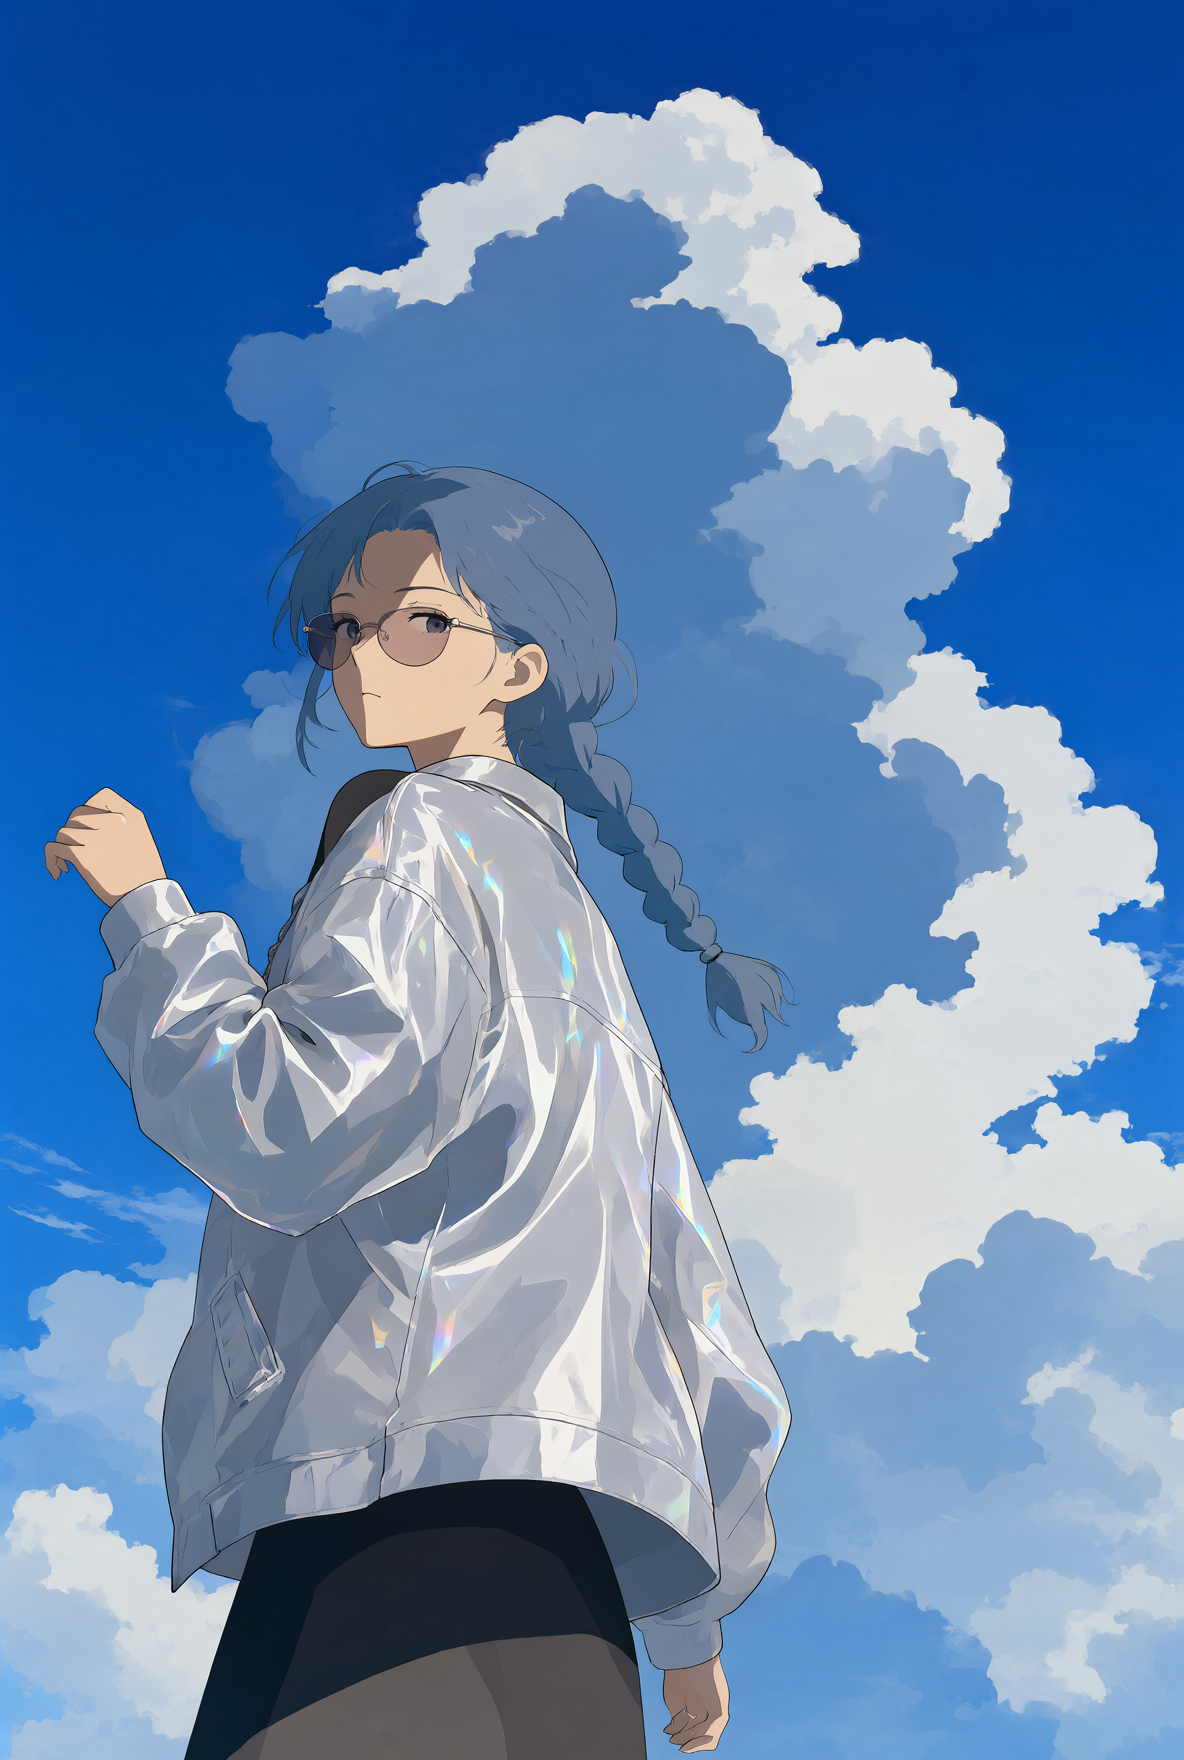

In [6]:
ksampler = noeud_de_classe(prompt_api, "KSampler")
resolution = noeud_de_classe(prompt_api, "ResolutionSelector")

MEGAPIXELS = 2 if BATCH_MODE == "true" else 4
resolution["inputs"]["megapixels"] = MEGAPIXELS
ksampler["inputs"]["seed"] = 20260925

debut = time.time()
images = client.executer(prompt_api, timeout=900)
duree = time.time() - debut

assert images, "Aucune image renvoyee par l'instance"
image_principale = images[0]
print(f"Generation : {duree:.0f} s -- {image_principale.size[0]}x{image_principale.size[1]} px ({MEGAPIXELS} MP demandes)")
display(image_principale)

### Lecture du resultat

L'illustration est le prompt de reference de l'editeur (femme en veste email
argentee, ciel de cumulonimbus), genere ici sans aucune modification du
workflow : ce temoin atteste que le palier INT8 versionne produit bien la
sortie attendue. Le temps mesure, rapporte a la reference 12 Go de l'editeur,
donne l'ordre de grandeur du gain de l'instance dediee.

## 5. Le seed change tout

La documentation de l'editeur insiste : a prompt constant, **la graine fait
une grande difference** sur la composition. C'est une propriete utile a
connaitre avant de conclure quoi que ce soit d'un essai unique -- trois
graines, meme prompt :

graine 20260925 : ok


graine 20260926 : ok


graine 20260927 : ok


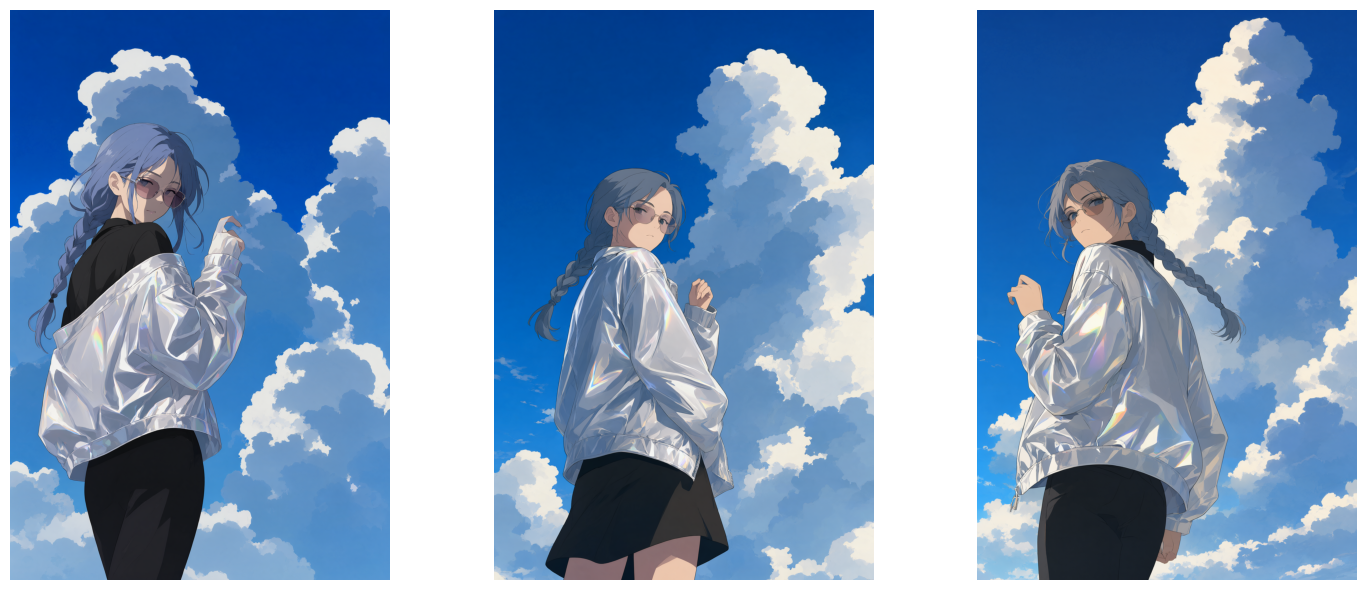

In [7]:
GRAINES = [20260925, 20260926, 20260927]
resolution["inputs"]["megapixels"] = 1

images_graines = []
for graine in GRAINES:
    ksampler["inputs"]["seed"] = graine
    images_graines.extend(client.executer(prompt_api, timeout=900))
    print(f"graine {graine} : ok")

fig, axes = plt.subplots(1, len(images_graines), figsize=(15, 6))
for ax, img in zip(axes, images_graines):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Lecture de la variance

Pose, orientation du regard, silhouette des nuages : les trois sorties sont
trois compositions distinctes d'une meme intention. La consequence pratique
est directe : un benchmark de prompt ou une comparaison de modeles qui ne
fixe pas la graine mesure du bruit, pas une difference.

## 6. Ce que l'instance couvre vraiment

Les 12 workflows versionnes ne demandent pas tous les memes noeuds : la
famille edit exige `TextEncodeQwenImage21` (ajoute avec le support 2.1 du
coeur ComfyUI), et deux workflows demandent des paquets custom. Plutot qu'une
table statique, le carnet interroge l'inventaire live `/object_info` : chaque
classe utilisee par un workflow doit y figurer pour qu'il soit executable
tel quel.

In [8]:
inventaire = set(client.object_info().keys())
print(f"Classes de noeuds disponibles sur l'instance : {len(inventaire)}")
print()

print(f"{'workflow':<26}{'noeuds':>7}   manquantes sur l'instance")
for chemin in sorted(DOSSIER_WF.glob("*.json")):
    wf = json.loads(chemin.read_text(encoding="utf-8"))
    classes = {n["type"] for n in wf["nodes"] if n["type"] not in ("MarkdownNote", "Note")}
    manquantes = classes - inventaire
    nom = chemin.name.replace("qwen_image_2_1_", "").replace(".json", "")
    etat = ", ".join(sorted(manquantes)) if manquantes else "-- 100 % couvert"
    print(f"{nom:<26}{len(classes):>4}     {etat}")

Classes de noeuds disponibles sur l'instance : 981

workflow                   noeuds   manquantes sur l'instance
image_edit                  11     -- 100 % couvert
image_edit_local            11     -- 100 % couvert
image_edit_local_mask       13     -- 100 % couvert
image_edit_openpose         13     OpenposePreprocessor
image_edit_upscale          11     -- 100 % couvert
layer_decomposition         21     Reroute, da2ffc0e-e6a8-4a06-8600-d26f7f23bbca
outpainting                 10     -- 100 % couvert
panorama                    10     PanoramaPreview
ref2image                   10     -- 100 % couvert
subject_extraction          11     -- 100 % couvert
text2image                  10     -- 100 % couvert


text2image_rgba             10     -- 100 % couvert


### Lecture de la couverture

Le tableau tranche ce qui reste executable : les workflows 100 % couverts
tournent tel quels (le convertisseur du §3 suffit), ceux dont il manque une
classe exigent soit une mise a jour du coeur ComfyUI de l'instance (voie
`RECOVERABLE-MACHINE` : decision d'hebergement, pas de carnet), soit un
paquet custom a installer (openpose, boucles de decomposition en calques).
Aucun de ces manquants n'est `INTRINSIC` : la limite est d'exploitation, pas
de nature.

## 7. Exercices

Trois exercices prolongent le carnet. Chacun part du code du corps sans
redefinir le client ni le convertisseur.

In [9]:
# Exercice 1 : l'echelle change-t-elle la composition ?
# Balayer megapixels dans (1, 2, 4) a graine fixee, afficher la grille 1x3,
# puis decrire ce qui survit du cadrage (sujet, place des nuages) et ce qui
# change (densite de detail). Comparer les durees mesurees.
# TODO etudiant
resultat_ex1 = None  # TODO etudiant : liste des 3 images

In [10]:
# Exercice 2 : la sortie RGBA.
# 1. Charger qwen_image_2_1_text2image_rgba.json depuis DOSSIER_WF et le
#    convertir avec ui_vers_api ;
# 2. Comparer le graphe obtenu au text2image du corps (qu'est-ce qui change,
#    qu'est-ce qui ne change pas ?) ;
# 3. Executer, puis examiner le mode de l'image PIL et son canal alpha
#    (minimum, maximum, moyenne) -- le prompt de reference demande explicitement
#    de la transparence.
# TODO etudiant
resultat_ex2 = None  # TODO etudiant

In [11]:
# Exercice 3 : pourquoi cfg = 1 ?
# Le negatif de reference passe par ConditioningZeroOut (zero pur). Ajouter au
# prompt_api un second noeud CLIPTextEncode (texte negatif, ex. "blurry, low
# quality", meme CLIPLoader que le positif) et repointer l'entree "negative" du
# KSampler vers lui. Tester cfg = 1.5 puis 2.0 a graine fixee, comparer aux
# sorties du §4. Conclure : le modele distille gagne-t-il quelque chose a un
# negatif redige ?
# Indice : dans prompt_api, une entree connectee vaut ["id_noeud", slot] --
# ajouter une cle au dict et repointer "negative" suffit, rien d'autre a cabler.
# TODO etudiant
resultat_ex3 = None  # TODO etudiant

## 8. Ce qu'il faut retenir

| Notion | Temooin dans ce carnet |
|---|---|
| Palier INT8 (3 fichiers, garde capacite) | garde de coherence §3 sur les chargeurs |
| Formats UI vs API de ComfyUI | convertisseur `ui_vers_api` et sa lecture |
| Workflow versionne = source de verite | chargement depuis `scripts/genai-stack/workflows/` |
| Modele distille : cfg = 1, negatif zero | `ConditioningZeroOut` du graphe de reference |
| Le seed domine la variance a prompt fixe | grille des 3 graines §5 |
| Couverture d'instance = question live | balayage `/object_info` §6 |

La lignee continue : les notebooks suivants attaqueront la famille edit
(`ref2image`, edition locale, outpainting) des que le coeur de l'instance
portera `TextEncodeQwenImage21` -- le §6 donne le test qui le detectera.